In [877]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [878]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScience_Projects/SupplyChain/supply_chain_data.csv")
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [879]:
# SKU is the identifier, make it into index
df.set_index("SKU", inplace = True)

### Dataset Overview

In [880]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, SKU0 to SKU99
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   Price                    100 non-null    float64
 2   Availability             100 non-null    int64  
 3   Number of products sold  100 non-null    int64  
 4   Revenue generated        100 non-null    float64
 5   Customer demographics    100 non-null    object 
 6   Stock levels             100 non-null    int64  
 7   Lead times               100 non-null    int64  
 8   Order quantities         100 non-null    int64  
 9   Shipping times           100 non-null    int64  
 10  Shipping carriers        100 non-null    object 
 11  Shipping costs           100 non-null    float64
 12  Supplier name            100 non-null    object 
 13  Location                 100 non-null    object 
 14  Lead time                1

## Defect
 
variables affecting defect
- 

In [881]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [882]:
df.duplicated().sum()

np.int64(0)

### Summary Statistics

In [883]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,100.0,49.462461,31.168193,1.699976,19.597823,51.239831,77.198228,99.171329
Availability,100.0,48.400000,30.743317,1.000000,22.750000,43.500000,75.000000,100.000000
Number of products sold,100.0,460.990000,303.780074,8.000000,184.250000,392.500000,704.250000,996.000000
Revenue generated,100.0,5776.048187,2732.841744,1061.618523,2812.847151,6006.352023,8253.976921,9866.465458
Stock levels,100.0,47.770000,31.369372,0.000000,16.750000,47.500000,73.000000,100.000000
Lead times,100.0,15.960000,8.785801,1.000000,8.000000,17.000000,24.000000,30.000000
Order quantities,100.0,49.220000,26.784429,1.000000,26.000000,52.000000,71.250000,96.000000
Shipping times,100.0,5.750000,2.724283,1.000000,3.750000,6.000000,8.000000,10.000000
Shipping costs,100.0,5.548149,2.651376,1.013487,3.540248,5.320534,7.601695,9.929816
Lead time,100.0,17.080000,8.846251,1.000000,10.000000,18.000000,25.000000,30.000000


In [884]:
df.describe(include="object").T

,count,unique,top,freq
Product type,100,3,skincare,40
Customer demographics,100,4,Unknown,31
Shipping carriers,100,3,Carrier B,43
Supplier name,100,5,Supplier 1,27
Location,100,5,Kolkata,25
Inspection results,100,3,Pending,41
Transportation modes,100,4,Road,29
Routes,100,3,Route A,43


### Numerical EDA

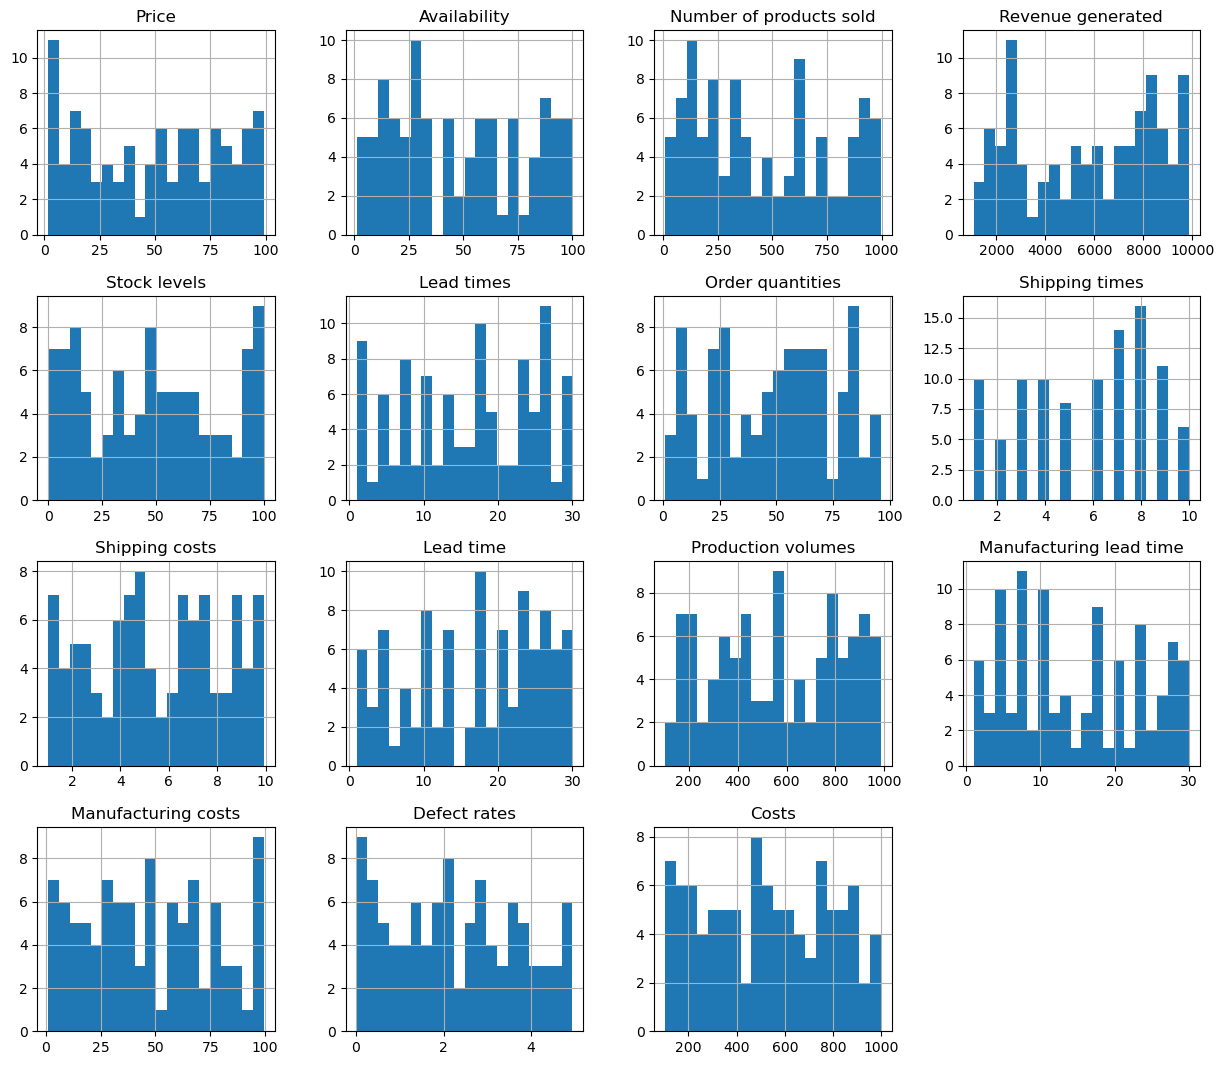

In [885]:
df.hist(figsize=(15,13), bins =20)
plt.show()

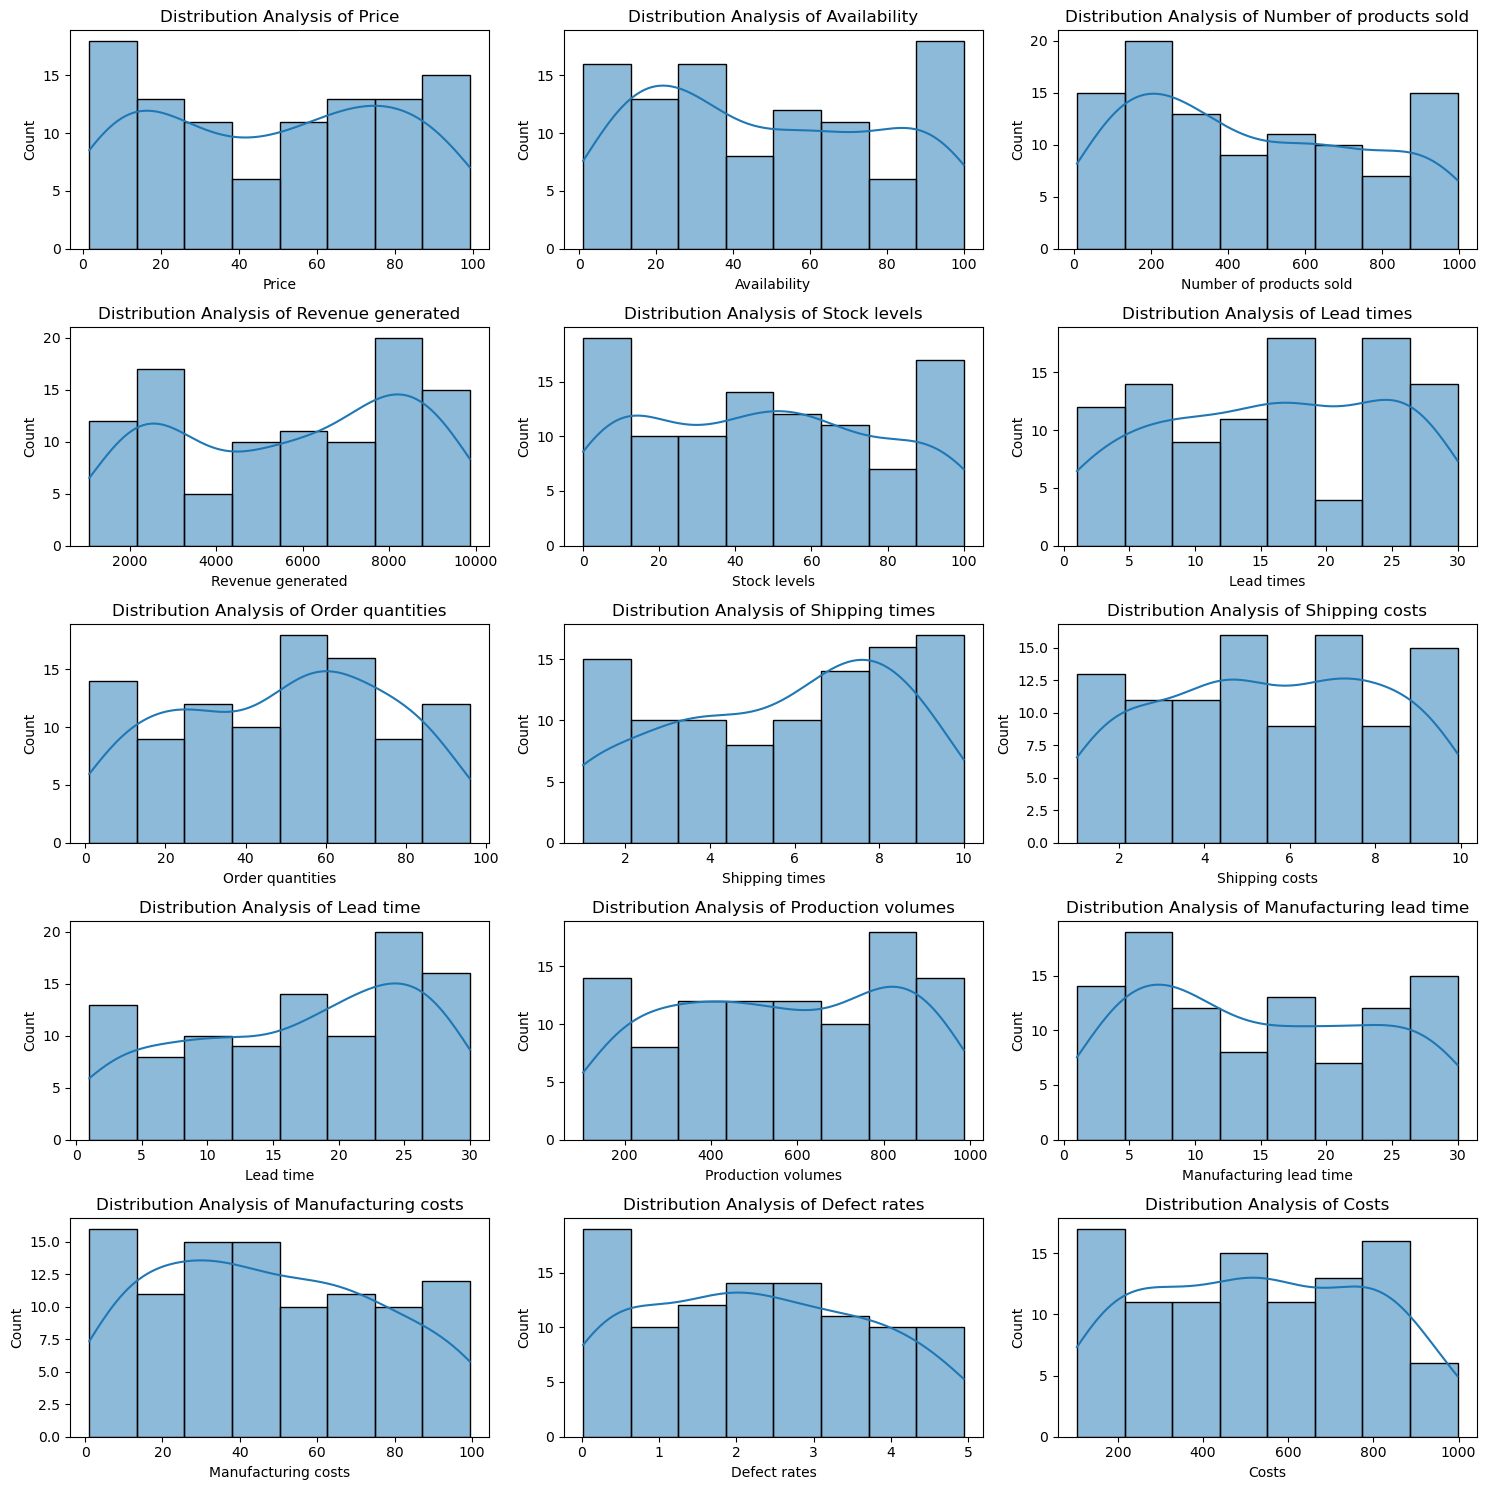

In [886]:
# Distribution Plot -> only for numerical columns

fig, axes = plt.subplots(5, 3, figsize = (15, 15))
axes = axes.flatten()

num_col = df.select_dtypes(include =  "number").columns
for i, j in enumerate(num_col):
    sns.histplot(df[j], kde = True, ax = axes[i])
    axes[i].set_title(f"Distribution Analysis of {j}")

plt.tight_layout()
plt.show()


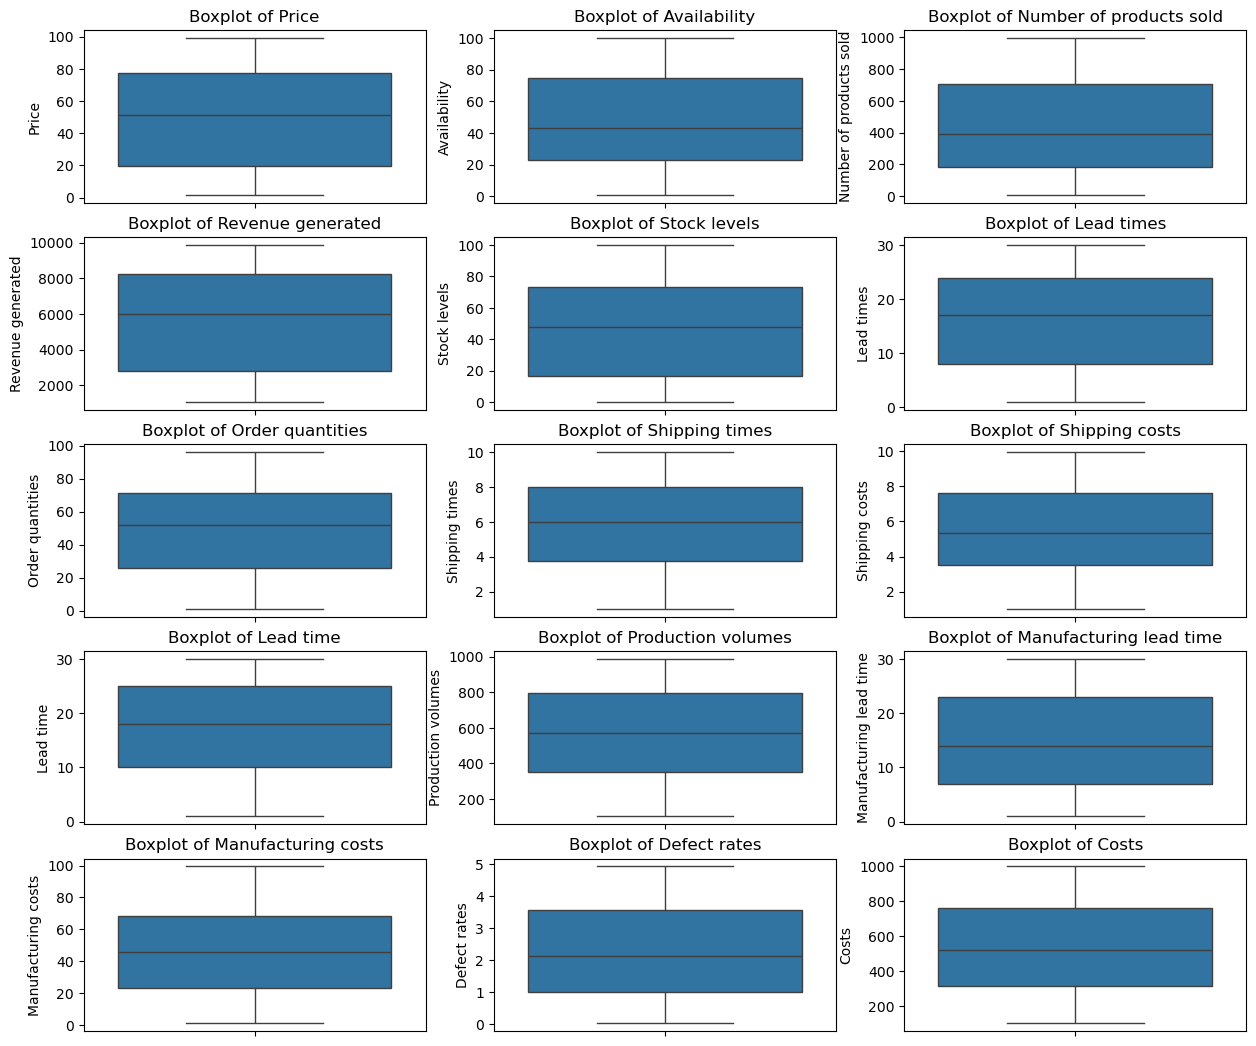

In [887]:
## Boxplot 
fig, axes = plt.subplots(5, 3 , figsize = (15, 13))
axes = axes.flatten()

for i, j in enumerate(num_col):
    sns.boxplot(df[j], ax = axes[i])
    axes[i].set_title(f"Boxplot of {j}")

plt.show()

In [888]:
## correlation matrix

### Categorical EDA
- value count
- count plot

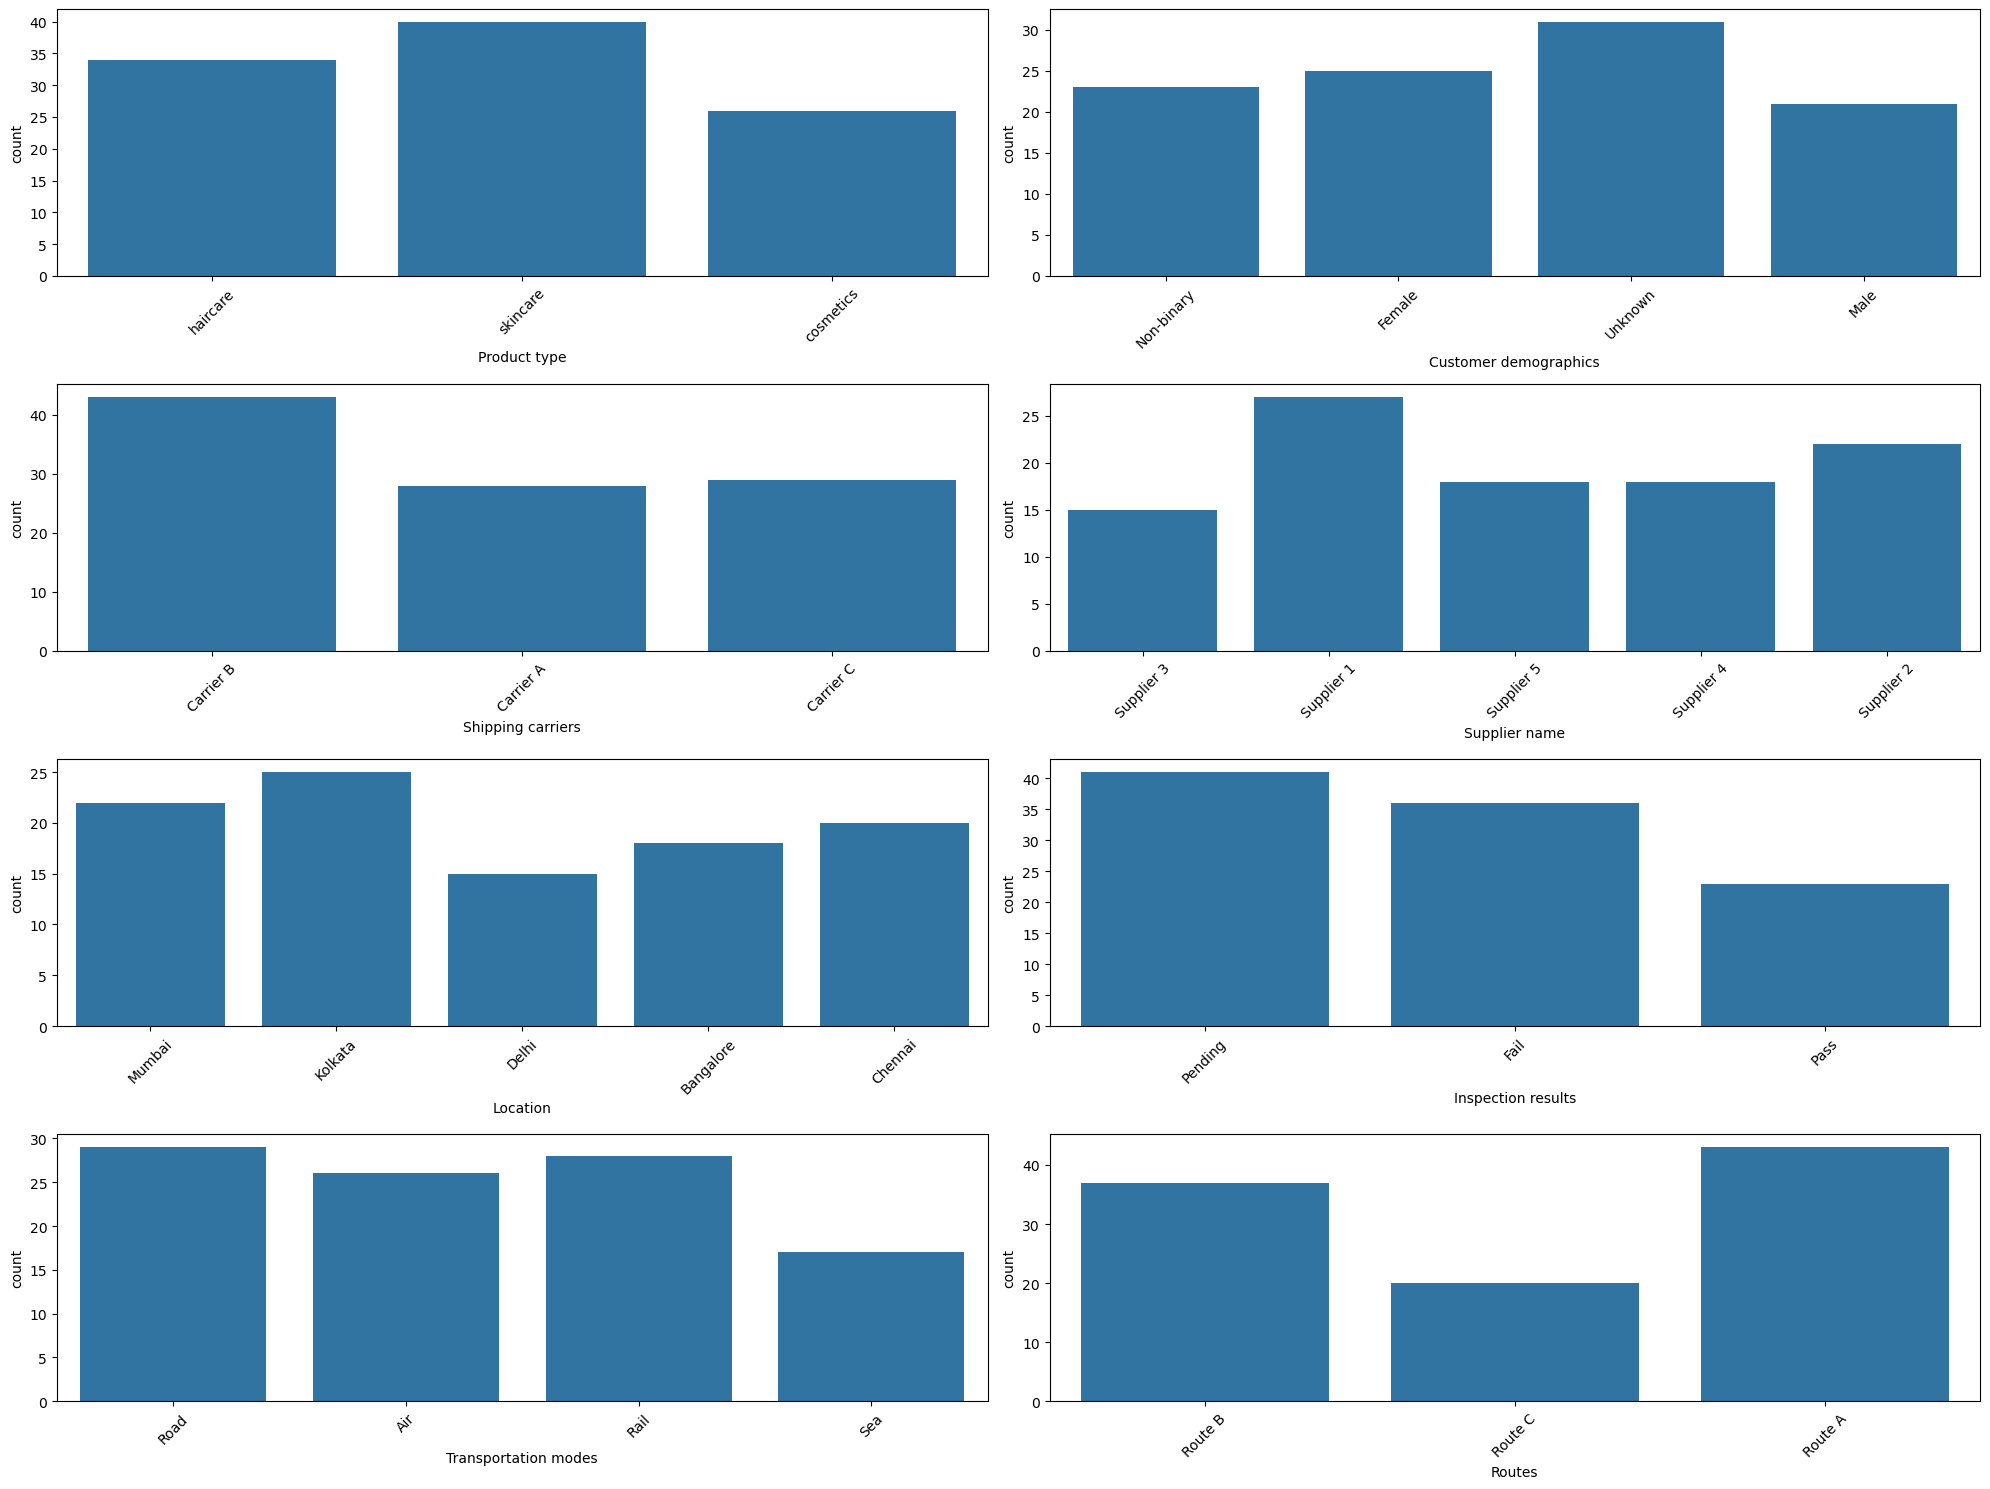

In [889]:
## Count plot - for categorical variables
fig, axes = plt.subplots(4, 2, figsize = (20, 15))
axes = axes.flatten()

cat_col = df.select_dtypes(include = "object").columns

for i, j in enumerate(cat_col):
    sns.countplot(
        data=df,
        x = j,
        ax = axes[i]
    )
    axes[i].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()

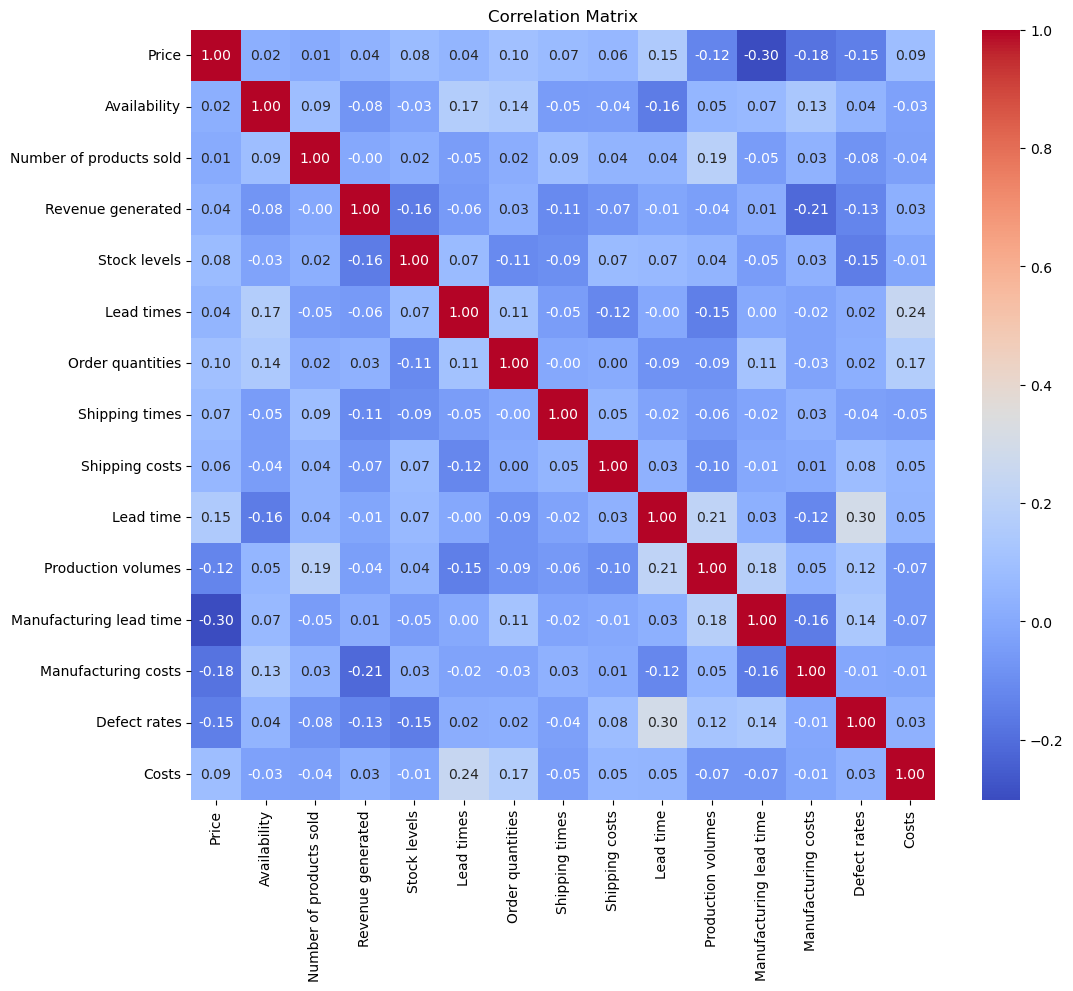

In [890]:
plt.figure(figsize=(12,10))

corr = df[num_col].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Relationship Analysis
- scatter plot
- pairplot

outlier detection 
kurtosis 
skewness


## Logistic Regression: Supply Chain Risk Score
- estimate the overall operational risk of a product
- High Defect = 1 --> High defect rate
- High Defect = 0 --> Low defect rate

In [891]:
df['Defect rates'].describe()

count    100.000000
mean       2.277158
std        1.461366
min        0.018608
25%        1.009650
50%        2.141863
75%        3.563995
max        4.939255
Name: Defect rates, dtype: float64

In [892]:
threshold = df['Defect rates'].median()

print("Defect Rate Threshold", threshold)

Defect Rate Threshold 2.141862683349868


In [893]:
df["High Defect"] = (
    df["Defect rates"] >= threshold
).astype(int)

In [894]:
df["High Defect"].value_counts(normalize=True)

High Defect
0    0.5
1    0.5
Name: proportion, dtype: float64

In [895]:
# must not use "Defect rates" as a predictor since we used it to create High defect

features = [
    "Product type",
    "Price",
    "Availability",
    "Stock levels",
    "Lead times",
    "Order quantities",
    "Shipping times",
    "Shipping carriers",
    "Shipping costs",
    "Supplier name",
    "Location",
    "Production volumes",
    "Manufacturing lead time",
    "Manufacturing costs",
    "Transportation modes",
    "Routes"
]

In [896]:
X = df[features].copy()

y = df["High Defect"].copy()

In [897]:
categorical_features = [
    "Product type",
    "Shipping carriers",
    "Supplier name",
    "Location",
    "Transportation modes",
    "Routes"
]

numerical_features = [
    col for col in features
    if col not in categorical_features
]

In [898]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [899]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# 5. Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [900]:
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [901]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[4 6]
 [6 4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.40      0.40        10
           1       0.40      0.40      0.40        10

    accuracy                           0.40        20
   macro avg       0.40      0.40      0.40        20
weighted avg       0.40      0.40      0.40        20



### Note: The goal is not to improve the model yet but to interpret the model first


- eda
- hypothesis testing
- build logistic regression as baseline
- put it against another ML algorithm
- compare results 
- showcase final model



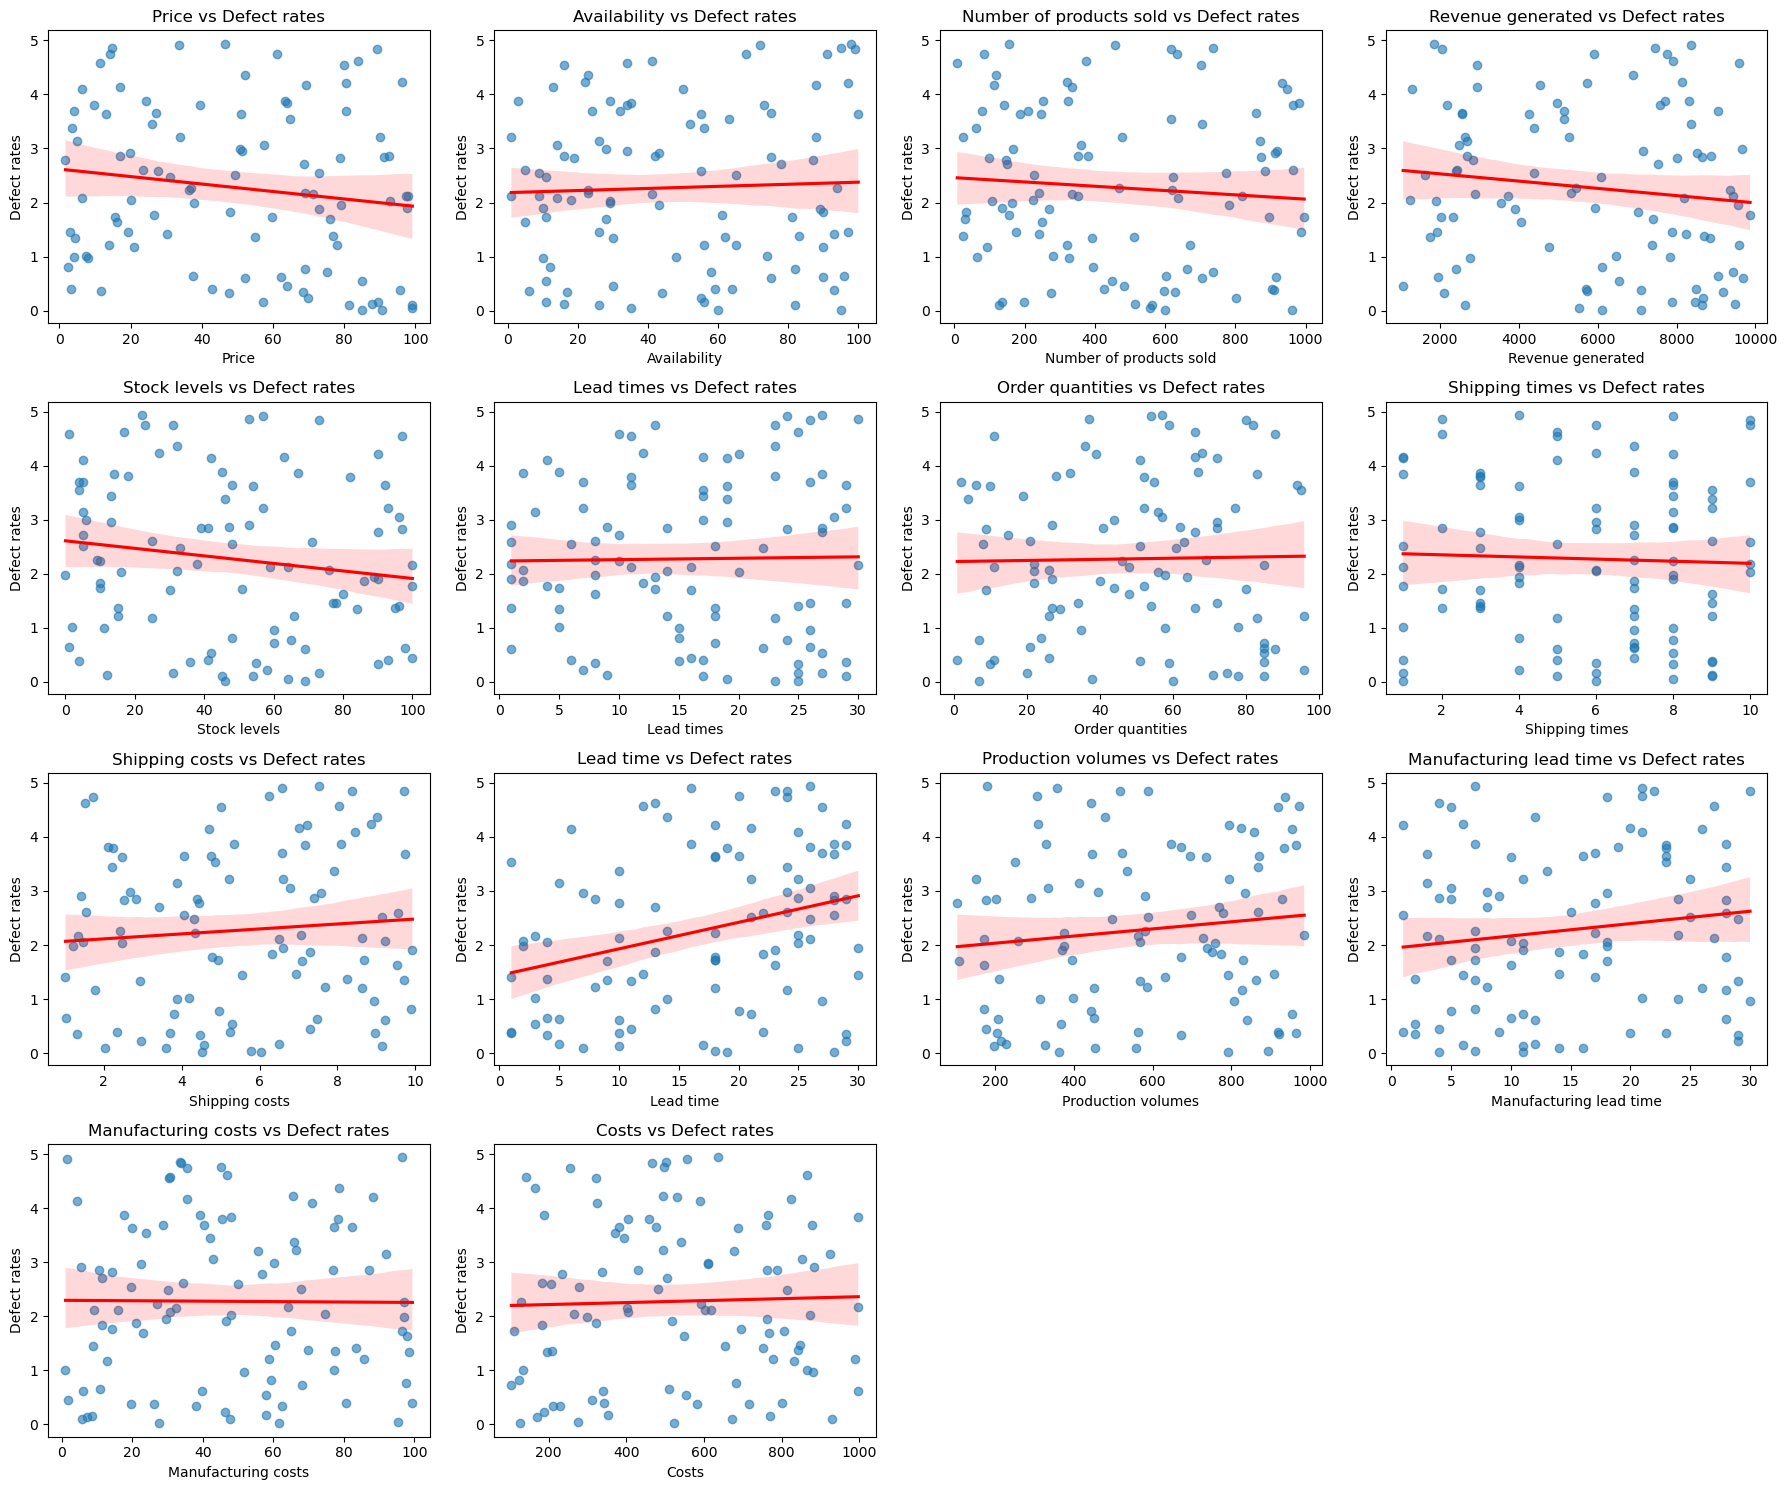

In [903]:
import matplotlib.pyplot as plt
import seaborn as sns

num_predictors = [
    col for col in num_col
    if col not in ["Defect rates", "High Defect"]
]

fig, axes = plt.subplots(
    4, 4,
    figsize=(18, 15)
)

axes = axes.flatten()

for i, col in enumerate(num_predictors):

    sns.regplot(
        data=df,
        x=col,
        y="Defect rates",
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )

    axes[i].set_title(
        f"{col} vs Defect rates"
    )

# Remove unused plots
for i in range(len(num_predictors), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()